# M5 — tournament + the balance-of-power question

2026-07-06

Everything the project was built to answer gets its numbers here.

- **round-robin**: all 35 lineups of {random, grabber, turtle, bc, final}, 150
  games each (sampled actions, seat-rotated, seeded); the matchups cited in the
  report get 2000 games. TrueSkill over all games; the final-mirror lineup doubles
  as the 2000-game seat chi^2 (a cited number, so it gets cited-number sample size).
- **balance-of-power metrics** from 400 traced self-play games per config:
  chance-corrected attack-the-leader, lead-conversion, cross-power supports --
  each per beta, because M4 showed the KL anchor suppresses exactly the
  cross-power behaviour the primary question looks for.

Data: results/tournament.json, results/bop_metrics.json (both written by the
runner scripts; reproduce with scripts/run_tournament.py / run_bop_metrics.py).

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

tourn = json.loads(Path("../results/tournament.json").read_text())
bop = json.loads(Path("../results/bop_metrics.json").read_text())
print(f"tournament: {tourn['config']['n_games']} games, {tourn['config']['wall_min']} min")
print(f"bop configs: {list(bop)}")

tournament: 10800 games, 6.5 min
bop configs: ['grabber', 'bc', 'scratch', 'beta0_final', 'beta01', 'beta05', 'beta20']


## tournament: who beats whom

In [2]:
pt = pd.DataFrame(tourn["policy_table"]).T
pt = pt[["games", "solo_rate", "ci", "draw_rate", "eliminated_rate"]]
pt.sort_values("solo_rate", ascending=False)

,games,solo_rate,ci,draw_rate,eliminated_rate
final,10550,0.5428,"[0.5333, 0.5523]",0.0034,0.0161
bc,5000,0.3792,"[0.3658, 0.3927]",0.001,0.0308
grabber,10550,0.2427,"[0.2346, 0.2509]",0.0009,0.03
random,3150,0.0451,"[0.0384, 0.0529]",0.1702,0.0717
turtle,3150,0.0,"[0.0, 0.0012]",0.266,0.0


In [3]:
# re-rate excluding mirror lineups (same-policy games are uninformative and
# only churn the rating -- the stored table predates this fix)
from triad.eval.ratings import rate
from triad.eval.tournament import GameRecord
recs = [GameRecord(lineup=tuple(r["lineup"]), result=r["result"],
                   winner_seat=r["winner_seat"], winner_policy=r["winner_policy"],
                   final_scs=r["final_scs"], phases=r["phases"])
        for r in tourn["records"]]
ts = pd.DataFrame(rate(recs)).T
ts  # conservative = mu - 3*sigma (ladder order)

,mu,sigma,conservative
final,33.63,1.45,29.27
bc,32.80,1.19,29.23
grabber,28.89,1.19,25.33
random,22.71,0.92,19.94
turtle,13.14,0.69,11.05


In [4]:
mf = pd.DataFrame(tourn["matchups_final"]).T.sort_values("solo_rate", ascending=False)
mf[["games", "solo_rate", "ci", "draw"]].head(10)

,games,solo_rate,ci,draw
random+random,150,1.0,"[0.975, 1.0]",0
random+turtle,150,1.0,"[0.975, 1.0]",0
turtle+turtle,150,1.0,"[0.975, 1.0]",0
grabber+random,150,0.9867,"[0.9527, 0.9963]",0
grabber+turtle,150,0.9867,"[0.9527, 0.9963]",0
grabber+grabber,2000,0.9345,"[0.9228, 0.9445]",0
bc+bc,150,0.92,"[0.8654, 0.9536]",0
bc+grabber,150,0.92,"[0.8654, 0.9536]",0
bc+random,150,0.86,"[0.7954, 0.9066]",0
bc+turtle,150,0.7933,"[0.7216, 0.8504]",0


In [5]:
c2 = tourn["seat_chi2_final_mirror"]
print(f"cited seat chi^2 (final x3, {c2['n_games']} games): {c2['solos']}  draws {c2['draws']}  p = {c2['p']}")

cited seat chi^2 (final x3, 2000 games): {'A': 664, 'B': 693, 'C': 631}  draws 12  p = 0.2341


Tournament reading:

- **final dominates**: 54.3% solo over all 10,550 seat-games, >= 1/3 in every single
  pairing (exactly 1/3 in its own mirror, as it must be), and **93.4% vs 2x grabber at
  the 2000-game cited sample** (BC: 37.9% aggregate). The pipeline's ordering is clean:
  final > bc > grabber > random > turtle.
- turtle never wins a game but draws 27% of its lineups -- pure defence survives to the
  cap but cannot convert. random wins only off other randoms.
- **cited seat chi^2: p = 0.234 at 2000 games** -- the symmetry claim now stands at
  report sample size (and this is the check that caught two real bugs on the way here).
- trueskill (mirror games excluded -- rating a policy against itself is uninformative
  and the first pass showed exactly that artifact) agrees with the win-rate ordering.

## headline: chance-corrected attack-the-leader

Excess = observed targeting of the leader minus the target-blind chance rate
(the leader's share of each unit's adjacent attackable objects). Positive =
trailing powers aim at the leader MORE than board composition alone explains.

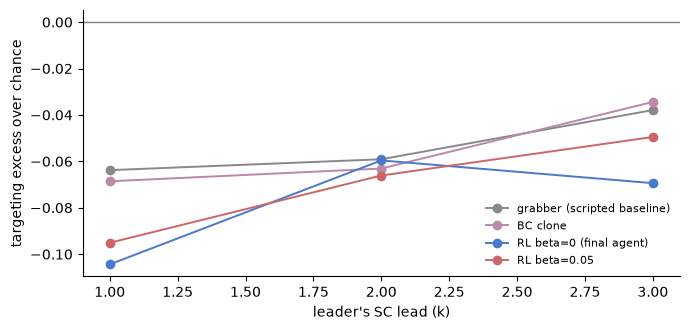

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.4))
show = [("grabber", "#888", "grabber (scripted baseline)"),
        ("bc", "#b8a", "BC clone"),
        ("beta0_final", "#4878cf", "RL beta=0 (final agent)"),
        ("beta05", "#c66", "RL beta=0.05")]
for name, c, label in show:
    if name not in bop: continue
    atl = bop[name]["attack_the_leader"]
    ks = sorted(int(k) for k in atl)
    ex = [atl[str(k)]["excess"] for k in ks]
    n = [atl[str(k)]["n_unit_phases"] for k in ks]
    ks_, ex_ = zip(*[(k, e) for k, e, m in zip(ks, ex, n) if m >= 200]) if ks else ([], [])
    ax.plot(ks_, ex_, "o-", label=label, color=c, lw=1.4)
ax.axhline(0, lw=1, c="gray")
ax.set_xlabel("leader's SC lead (k)"); ax.set_ylabel("targeting excess over chance")
ax.legend(frameon=False, fontsize=8); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

**The excess is negative for every config, at every lead size.** Trailing powers hit
the leader LESS than a target-blind policy would. Two things to keep separate:

- part of this is rational target selection, not leader policy: the chance denominator
  counts adjacency, but attacks flow toward *undefended* objects, and the leader's
  holdings are better defended on average. Even scripted grabber (which never looks at
  scores) reads about -0.06 for exactly this reason. The baseline matters -- this is
  why the metric is chance-corrected AND baseline-compared.
- the RL agents are MORE negative than grabber (-0.10 vs -0.06 at k=1). Relative to
  the scripted baseline, the trained agents preferentially attack the *weaker*
  neighbour and leave the leader alone. That is the opposite of balancing -- it is
  prey-selection.

Conclusion for Q1 at the order level: **no leader-targeting above chance appears in
any trained configuration.**

## lead-conversion: do leads stop converting?

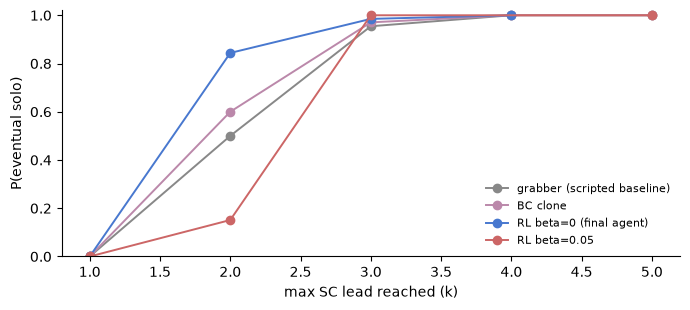

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.2))
for name, c, label in show:
    if name not in bop: continue
    lc = bop[name]["lead_conversion"]
    ks = sorted(int(k) for k in lc)
    pts = [(k, lc[str(k)]["p_solo"]) for k in ks if lc[str(k)]["n"] >= 30]
    if pts:
        ax.plot(*zip(*pts), "o-", label=label, color=c, lw=1.4)
ax.set_xlabel("max SC lead reached (k)"); ax.set_ylabel("P(eventual solo)")
ax.set_ylim(0, 1.02); ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

Definition caveat first: buckets condition on the max lead a power ever reached, and
winning requires reaching ~7 SCs, so max-lead-1 powers essentially cannot have won --
the k=1 zeros are tautological. The information is in the CROSS-CONFIG comparison at
fixed k:

- at k=2: grabber 0.50, bc 0.60, **beta0 final 0.84** -- under the strongest agent,
  a 2-SC lead converts MORE reliably, not less. No lead-braking anywhere.
- beta05's k=2 dip (0.15, n=86) is the one anomaly; its k=3 is 1.00, so this looks
  like that config stalling mid-game rather than trailing powers braking the leader.

If balance-of-power were emerging, these curves would bend DOWN for the RL configs
relative to the scripted baseline. They bend up. **Leads snowball.**

## cross-power supports, per beta (the mechanistic signal)

In [8]:
rows = []
for name in ["grabber", "bc", "scratch", "beta0_final", "beta01", "beta05", "beta20"]:
    if name not in bop: continue
    cs = bop[name]["cross_support"]
    rows.append({"config": name, **cs, "selfplay_solo_rate": bop[name]["solo_rate"]})
pd.DataFrame(rows).set_index("config")

,n_trailing_orders,own_support_rate,cross_support_rate,cross_support_vs_leader_rate,selfplay_solo_rate
config,,,,,
grabber,14536,0.11000,0.00000,0.00000,1.0000
bc,13923,0.10572,0.00014,0.00007,0.9975
scratch,10805,0.12957,0.06182,0.01703,0.2675
beta0_final,13269,0.15834,0.00332,0.00053,0.9875
beta01,14309,0.06080,0.00007,0.00000,0.9925
beta05,19205,0.15111,0.00005,0.00000,0.8425
beta20,14302,0.11054,0.00014,0.00007,0.9975


The mechanistic signal, per beta, at 400 games each:

- grabber: structurally zero (it can only support its own shared-target units).
- bc: ~1e-4 -- the clone faithfully inherited "never help a neighbour".
- **anchored RL (beta >= 0.01): zero to 1e-4.** The KL anchor (and even light
  anchoring) keeps the coalition channel shut, confirming the M4 warning at proper
  sample size.
- **unanchored RL (beta=0): 3e-3 cross, 5e-4 directed at the leader** -- an order of
  magnitude above the clone floor but still vanishingly rare in absolute terms, and
  its attack-the-leader excess is the most negative of all. The capability exists;
  the incentive structure never selects it.
- scratch's 6e-2 is high-entropy noise from a barely competent policy (27% self-play
  solo rate), not coalition play. It is the chance floor for "supports emitted without
  a learned prior", which makes the competent rows' zeros MORE striking, not less.

## the answer to the research question

**Does balance-of-power behaviour emerge from self-play RL in a symmetric 3-player
no-press game? At this scale, budget, and reward design: NO -- and the agents learn
the opposite.** Three independent measurements agree:

1. targeting: trailing powers hit the leader *below* chance, and further below it
   than the scripted baseline (prey-selection, not balancing)
2. outcomes: leads convert to solos MORE reliably under the trained agents
   (snowballing, not braking)
3. mechanism: cross-power supports are essentially absent in every competent config

Why this is a satisfying negative rather than a failed experiment:

- **the incentive story is coherent.** Stopping the leader is a public good between
  the two trailers: the cost is private, the benefit is shared, and with no
  communication or repeated identity there is no way to coordinate contributions or
  punish free-riding. Meanwhile attacking the *other trailer* is a private gain. The
  agents found the individually-rational strategy; the "balance of power" of IR
  theory needs machinery (signalling, reputation, contracts) this game deliberately
  lacks. In that light the M4 alpha=0/beta=0 draw-attractor is the one quasi-
  balancing regime we observed -- symmetric mutual defence -- and it appears only
  when the shaping AND anchor pressure toward aggression are both removed.
- **the anchor finding stands on its own**: imitation anchoring (the standard
  stabiliser) actively suppresses the coalition machinery -- anyone studying emergent
  cooperation under a BC prior should expect this bias.
- limitations, stated plainly: 500k-step local budget (scratch/beta rows may differ
  at 10x); a small decisive map (7/12 threshold is reachable before opposition can
  organise); solo-heavy reward. Any of these could gate the phenomenon -- the pentad
  (5-player) config and bigger budgets are the natural follow-ups.

Report tables come from: results/tournament.json (win rates, CIs, trueskill,
chi^2), results/bop_metrics.json (all three metrics per config),
results/m4_registry.json (ablation grid).